# Loan Portfolio Risk Analytics

This project evaluates borrower- and loan-level default risk using an analysis-ready dataset prepared in MySQL. Python is used for portfolio summaries, multivariate risk segmentation, hypothesis testing, and visualization.

**Tools:** Python, pandas, NumPy, Matplotlib, SciPy, statsmodels  
**Outcome variable:** `Default` (`1` = default, `0` = non-default)


## 1. Setup and Data Import

The notebook expects the repository structure:

```text
Loan-Portfolio-Risk-Analytics/
├── data/
│   └── loan_analysis_ready.csv
├── notebooks/
│   └── loan_risk_analysis.ipynb
└── outputs/
```


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

os.makedirs("../outputs", exist_ok=True)


In [ ]:
df = pd.read_csv("../data/loan_analysis_ready.csv")
df.head()


## 2. Data Validation

Confirm that the analysis-ready dataset has no missing values in the imported fields and review the observed default distribution.


In [39]:
df.isnull().sum()


LoanID               0
Age                  0
Income               0
LoanAmount           0
CreditScore          0
MonthsEmployed       0
NumCreditLines       0
InterestRate         0
LoanTerm             0
DTIRatio             0
Education            0
EmploymentType       0
MaritalStatus        0
HasMortgage          0
HasDependents        0
LoanPurpose          0
HasCoSigner          0
Default              0
credit_score_band    0
dti_band             0
dtype: int64

In [ ]:
df.duplicated(subset="LoanID").sum()


In [40]:
df["Default"].value_counts()


Default
0    881
1    119
Name: count, dtype: int64

## 3. Portfolio Summary

Create a compact set of portfolio-level KPIs for use in the final project summary.


In [41]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Average Loan Amount",
        "Average Income",
        "Average Credit Score",
        "Average Interest Rate",
        "Default Rate"
    ],
    "Value": [
        len(df),
        df["LoanAmount"].mean(),
        df["Income"].mean(),
        df["CreditScore"].mean(),
        df["InterestRate"].mean(),
        df["Default"].mean() * 100
    ]
})

portfolio_summary


,Metric,Value
0,Total Loans,1000.00000
1,Average Loan Amount,128328.56400
2,Average Income,83247.85800
3,Average Credit Score,574.48200
4,Average Interest Rate,13.80893
5,Default Rate,11.90000


## 4. Univariate Risk Segmentation

Compare observed default rates across credit-score, DTI, loan-purpose, and employment segments.


In [42]:
credit_summary = (
    df.groupby("credit_score_band", observed=False)
      .agg(
          total_loans=("LoanID", "count"),
          avg_loan_amount=("LoanAmount", "mean"),
          default_rate=("Default", "mean")
      )
      .reset_index()
)

credit_summary["default_rate"] *= 100
credit_summary


,credit_score_band,total_loans,avg_loan_amount,default_rate
0,500-599,188,130169.792553,12.234043
1,600-699,200,128056.795000,11.000000
2,700+,254,125411.350394,9.055118
3,Below 500,358,129583.243017,14.245810


In [43]:
dti_summary = (
    df.groupby("dti_band", observed=False)
      .agg(
          total_loans=("LoanID", "count"),
          avg_loan_amount=("LoanAmount", "mean"),
          default_rate=("Default", "mean")
      )
      .reset_index()
)

dti_summary["default_rate"] *= 100
dti_summary


,dti_band,total_loans,avg_loan_amount,default_rate
0,High DTI,506,128661.567194,12.845850
1,Low DTI,245,120775.636735,11.428571
2,Medium DTI,249,135083.453815,10.441767


In [45]:
purpose_summary = (
    df.groupby("LoanPurpose")
      .agg(
          total_loans=("LoanID", "count"),
          avg_loan_amount=("LoanAmount", "mean"),
          default_rate=("Default", "mean")
      )
      .reset_index()
)

purpose_summary["default_rate"] *= 100
purpose_summary.sort_values("default_rate", ascending=False)


,LoanPurpose,total_loans,avg_loan_amount,default_rate
4,Other,185,140882.016216,15.135135
2,Education,212,128602.735849,12.264151
1,Business,196,122449.051020,11.734694
0,Auto,207,124914.396135,11.111111
3,Home,200,125721.585000,9.500000


In [46]:
employment_summary = (
    df.groupby("EmploymentType")
      .agg(
          total_loans=("LoanID", "count"),
          default_rate=("Default", "mean")
      )
      .reset_index()
)

employment_summary["default_rate"] *= 100
employment_summary.sort_values("default_rate", ascending=False)


,EmploymentType,total_loans,default_rate
1,Part-time,220,14.090909
3,Unemployed,268,13.432836
2,Self-employed,258,10.852713
0,Full-time,254,9.448819


### Observed segment-level findings

- The overall observed default rate is **11.9%**.
- Borrowers with credit scores **below 500** have the highest credit-band default rate at **14.25%**.
- **High-DTI** borrowers have an observed default rate of **12.85%**.
- The **Other** loan-purpose category has the highest observed purpose-level default rate at **15.14%**.
- **Part-time** borrowers have the highest observed employment-group default rate at **14.09%**.

These are descriptive relationships and should not be interpreted as causal effects.


## 5. Multivariate Risk Segmentation

A pivot table examines the interaction between credit quality and leverage instead of evaluating each characteristic separately.


In [44]:
risk_matrix = pd.pivot_table(
    df,
    values="Default",
    index="credit_score_band",
    columns="dti_band",
    aggfunc="mean"
) * 100

risk_matrix


dti_band,High DTI,Low DTI,Medium DTI
credit_score_band,,,
500-599,17.647059,9.615385,5.882353
600-699,10.714286,10.256410,12.244898
700+,7.299270,10.638298,11.428571
Below 500,16.279070,13.084112,11.392405


In [49]:
df["high_risk_flag"] = np.where(
    (df["CreditScore"] < 600) &
    (df["DTIRatio"] > 0.50),
    1,
    0
)

high_risk_summary = (
    df.groupby("high_risk_flag")
      .agg(
          total_loans=("LoanID", "count"),
          default_rate=("Default", "mean")
      )
)

high_risk_summary["default_rate"] *= 100
high_risk_summary


,total_loans,default_rate
high_risk_flag,,
0,753,10.358566
1,247,16.599190


The rule-based high-risk segment (`CreditScore < 600` and `DTIRatio > 0.50`) shows an observed default rate of **16.60%**, compared with **10.36%** for the remaining loans.


## 6. Correlation Analysis

Pearson correlations provide a descriptive view of linear relationships between numeric characteristics and the binary default indicator.


In [51]:
numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "Default"
]

correlation_matrix = df[numeric_cols].corr()
default_correlations = correlation_matrix["Default"].sort_values(ascending=False)

default_correlations


Default           1.000000
InterestRate      0.130598
LoanAmount        0.078956
NumCreditLines    0.024523
DTIRatio          0.008484
LoanTerm         -0.036656
MonthsEmployed   -0.038430
CreditScore      -0.065808
Income           -0.074786
Age              -0.239197
Name: Default, dtype: float64

In this sample, `InterestRate` has the strongest positive linear correlation with default among the listed numeric variables, while `Age` has the strongest negative correlation. Correlation alone does not establish causation.


## 7. Statistical Hypothesis Testing

Two-proportion z-tests are used because the outcome is binary and the analysis compares observed default proportions between borrower groups.

A 5% significance threshold (`p < 0.05`) is used.


In [70]:
low_credit = df[df["CreditScore"] < 600]["Default"]
high_credit = df[df["CreditScore"] >= 700]["Default"]

count = [low_credit.sum(), high_credit.sum()]
nobs = [len(low_credit), len(high_credit)]

z_stat, p_value = proportions_ztest(count, nobs)

print("Low credit default rate:", low_credit.mean() * 100)
print("High credit default rate:", high_credit.mean() * 100)
print("Z-statistic:", z_stat)
print("P-value:", p_value)


Low credit default rate: 13.553113553113553
High credit default rate: 9.05511811023622
Z-statistic: 1.8143190249747112
P-value: 0.06962862421159395


**Interpretation:** The observed default rate is higher for borrowers with credit scores below 600, but the difference is **not statistically significant at the 5% level** (`p ≈ 0.070`).


In [72]:
high_dti = df[df["DTIRatio"] >= 0.50]["Default"]
low_dti = df[df["DTIRatio"] < 0.30]["Default"]

count = [high_dti.sum(), low_dti.sum()]
nobs = [len(high_dti), len(low_dti)]

z_stat, p_value = proportions_ztest(count, nobs)

print("High DTI default rate:", high_dti.mean() * 100)
print("Low DTI default rate:", low_dti.mean() * 100)
print("Z-statistic:", z_stat)
print("P-value:", p_value)


High DTI default rate: 12.845849802371543
Low DTI default rate: 11.428571428571429
Z-statistic: 0.5528139685714729
P-value: 0.5803908024563302


**Interpretation:** The observed default-rate difference between high- and low-DTI borrowers is **not statistically significant at the 5% level** (`p ≈ 0.580`).


## 8. Product × Borrower Risk Analysis

The next analysis identifies higher-risk combinations of credit band, DTI band, and loan purpose while excluding very small cells from the ranking.


In [60]:
combined_risk = (
    df.groupby(
        ["credit_score_band", "dti_band", "LoanPurpose"],
        observed=False
    )
    .agg(
        total_loans=("LoanID", "count"),
        default_rate=("Default", "mean")
    )
    .reset_index()
)

combined_risk["default_rate"] *= 100

top_combined_risk = (
    combined_risk[combined_risk["total_loans"] >= 30]
    .sort_values("default_rate", ascending=False)
    .head(10)
)

top_combined_risk


,credit_score_band,dti_band,LoanPurpose,total_loans,default_rate
47,Below 500,High DTI,Education,35,20.000000
45,Below 500,High DTI,Auto,37,18.918919
49,Below 500,High DTI,Other,38,15.789474
46,Below 500,High DTI,Business,34,11.764706
18,600-699,High DTI,Home,30,10.000000
32,700+,High DTI,Education,35,5.714286


The highest observed multi-factor default rates among segments with at least 30 loans are:

- **Below-500 credit + High DTI + Education:** **20.0%**
- **Below-500 credit + High DTI + Auto:** **18.92%**
- **Below-500 credit + High DTI + Other:** **15.79%**

These subgroup results are descriptive and should be monitored over larger samples before being converted into hard underwriting thresholds.


## 9. Visualizations


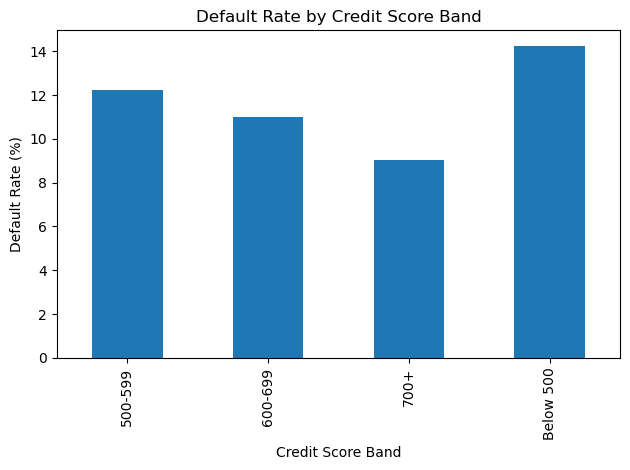

In [67]:
credit_chart = (
    df.groupby("credit_score_band", observed=False)["Default"]
      .mean() * 100
)

credit_chart.plot(kind="bar")
plt.xlabel("Credit Score Band")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Credit Score Band")
plt.tight_layout()
plt.savefig("../outputs/credit_score_default_rate.png", dpi=300, bbox_inches="tight")
plt.show()


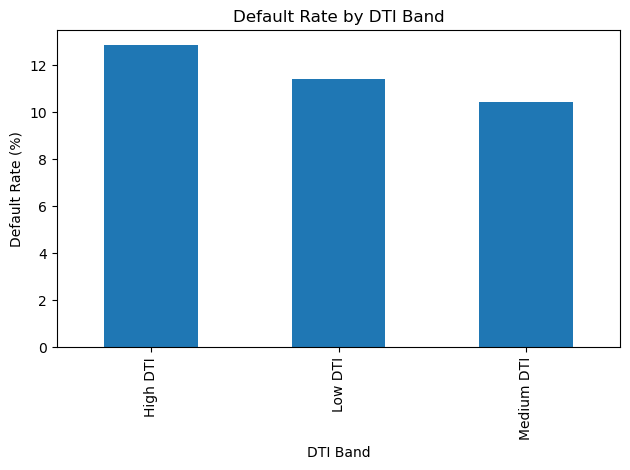

In [66]:
dti_chart = (
    df.groupby("dti_band", observed=False)["Default"]
      .mean() * 100
)

dti_chart.plot(kind="bar")
plt.xlabel("DTI Band")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by DTI Band")
plt.tight_layout()
plt.savefig("../outputs/dti_default_rate.png", dpi=300, bbox_inches="tight")
plt.show()


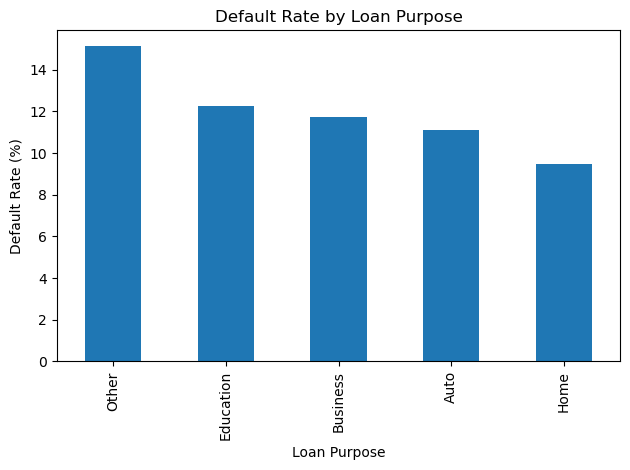

In [64]:
purpose_chart = (
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .sort_values(ascending=False) * 100
)

purpose_chart.plot(kind="bar")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Purpose")
plt.tight_layout()
plt.savefig("../outputs/loan_purpose_default_rate.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Key Findings and Recommendation

### Key findings

1. The portfolio has an observed default rate of **11.9%** across 1,000 loans.
2. Default risk is more pronounced in certain **multi-factor borrower/product segments** than in single-variable comparisons.
3. A rule-based low-credit/high-DTI segment records a **16.60%** observed default rate versus **10.36%** for the rest of the portfolio.
4. The highest observed combined-risk segments include below-500 credit, high-DTI borrowers in Education and Auto lending.
5. Credit score and DTI differences tested individually were not statistically significant at the 5% level in this sample.

### Recommendation

The lender should use a **targeted portfolio-monitoring approach** rather than impose broad underwriting restrictions based on a single characteristic. Borrowers displaying multiple elevated risk indicators—particularly weak credit quality combined with high leverage in higher-default loan-purpose segments—should receive enhanced affordability review and monitoring.

Because standalone credit-score and DTI differences were not statistically significant in this 1,000-loan sample, these variables should not be treated as sufficient evidence for hard approval cutoffs on their own. The higher-risk multi-factor segments should instead be validated on larger samples and tracked over time before being incorporated into formal underwriting policy.

This project is an educational portfolio analysis and is not a production credit-scoring model.


## 11. Export Analysis Tables

The following exports are optional and can be used for downstream reporting.


In [ ]:
portfolio_summary.to_csv("../outputs/portfolio_summary.csv", index=False)
credit_summary.to_csv("../outputs/credit_summary.csv", index=False)
dti_summary.to_csv("../outputs/dti_summary.csv", index=False)
purpose_summary.to_csv("../outputs/purpose_summary.csv", index=False)
employment_summary.to_csv("../outputs/employment_summary.csv", index=False)
combined_risk.to_csv("../outputs/combined_risk.csv", index=False)
risk_matrix.to_csv("../outputs/risk_matrix.csv")
